# Phase 3.5 — Serrer la régularisation à `window = 60`

**Constats Phase 3 :**
1. À fenêtre 30 RR, le CNN-LSTM tuné plafonne à AUROC **0.955** et F1/patient **0.66**, sous le HRV+RF (0.986 / 0.85).
2. À fenêtre 60 RR (sans recherche dédiée), il monte déjà à **0.977 / 0.73**.
3. Les courbes d'apprentissage montrent un sur-apprentissage net : val_loss diverge alors que train_loss continue de baisser.

**Hypothèse Phase 3.5 :** une recherche Optuna *dédiée* à `window=60`, avec :
- dropouts plus agressifs (0.2-0.5 sur le CNN, 0.3-0.6 sur la head),
- ajout d'un `weight_decay` AdamW (1e-5 à 3e-3 log-uniforme),
- **early stopping sur AUROC** (plus stable que la BCE pondérée),
- patience augmentée à 4 epochs,

doit refermer l'écart F1/patient avec HRV+RF, voire le dépasser.

Toujours **5-fold patient-level CV** au final, donc apples-to-apples avec tout ce qui précède.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, roc_auc_score, f1_score
import optuna
from optuna.samplers import TPESampler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.baselines.cv import crossval_torch_oof, train_with_history
from src.data.loader import list_records, load_record_metadata
from src.data.rr_extract import clean_rr_series, extract_rr_series
from src.data.windowing import build_windowed_dataset
from src.models.cnn_lstm import CNNLSTM
from src.utils.metrics import per_patient_f1, ranking_metrics, threshold_metrics
from src.utils.seed import set_seed
from src.utils.splits import patient_kfold

set_seed(42)
torch.set_num_threads(4)
optuna.logging.set_verbosity(optuna.logging.WARNING)

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
RES_DIR = PROJECT_ROOT / "reports"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

WINDOW = 60
STRIDE = 30
N_TRIALS = 25
N_SPLITS_SEARCH = 3
N_SPLITS_FINAL = 5
SEED = 42
print("Project root:", PROJECT_ROOT, "| threads:", torch.get_num_threads())

Project root: /home/abdou/Master | threads: 4


In [2]:
def build_afdb_windows(window: int, stride: int):
    dataset_dir = PROJECT_ROOT / "data" / "raw" / "afdb"
    series_by_patient = {}
    for rec in list_records(dataset_dir):
        try:
            meta = load_record_metadata(dataset_dir, rec)
            s = clean_rr_series(extract_rr_series(meta))
            if len(s.rr_seconds) >= window:
                series_by_patient[rec] = s
        except Exception:
            continue
    w = build_windowed_dataset(series_by_patient, window_size=window, stride=stride, label_strategy="majority")
    return w.X.astype(np.float32), w.y.astype(np.int8), np.asarray(w.patient_id)

t0 = time.time()
X, y, groups = build_afdb_windows(WINDOW, STRIDE)
print(f"AFDB w={WINDOW}: X={X.shape}, AFib={y.mean():.3f}, patients={len(np.unique(groups))} ({time.time()-t0:.1f}s)")

# Baseline floor (Phase 2 / Phase 3)
baselines = json.loads((RES_DIR / "baselines_summary.json").read_text())
phase3 = json.loads((RES_DIR / "phase3_results.json").read_text())
print("\nFloor à battre (HRV+RF, Phase 2):")
for k in ("auroc", "auprc", "f1", "mean_patient_f1"):
    print(f"  {k:18s} = {baselines['hrv_rf'][k]:.4f}")
print("\nMeilleur Phase 3 (CNN-LSTM w=60 default Optuna params):")
for k in ("auroc", "auprc", "f1", "mean_patient_f1"):
    print(f"  {k:18s} = {phase3['ablation']['window60'][k]:.4f}")

AFDB w=60: X=(40613, 60), AFib=0.436, patients=25 (3.1s)

Floor à battre (HRV+RF, Phase 2):
  auroc              = 0.9863
  auprc              = 0.9795
  f1                 = 0.9316
  mean_patient_f1    = 0.8459

Meilleur Phase 3 (CNN-LSTM w=60 default Optuna params):
  auroc              = 0.9767
  auprc              = 0.9660
  f1                 = 0.9133
  mean_patient_f1    = 0.7320


## 1. Recherche Optuna — régularisation serrée

Espace de recherche resserré (vs Phase 3) sur les leviers anti-overfit :

- `cnn_dropout` ∈ [0.2, 0.5]  (vs [0.1, 0.4])
- `head_dropout` ∈ [0.3, 0.6] (vs [0.1, 0.5])
- nouveau : `weight_decay` ∈ [1e-5, 3e-3] log
- `cnn_first` ∈ {8, 16} — on enlève 24 car le modèle est trop large pour 60 RR
- `lr` ∈ [3e-4, 2e-3] log (resserré)
- `early_stop_metric = "auroc"`, `patience = 4`

In [3]:
def cnn_lstm_factory_from_params(p: dict, input_length: int):
    if p["n_cnn_blocks"] == 2:
        channels = (p["cnn_first"], p["cnn_first"] * 2)
    else:
        channels = (p["cnn_first"], p["cnn_first"] * 2, p["cnn_first"] * 4)
    return CNNLSTM(
        input_length=input_length,
        cnn_channels=channels,
        kernel_size=p["kernel_size"],
        pool_size=2,
        cnn_dropout=p["cnn_dropout"],
        batch_norm=True,
        lstm_hidden=p["lstm_hidden"],
        lstm_layers=p["lstm_layers"],
        bidirectional=True,
        lstm_dropout=0.2 if p["lstm_layers"] > 1 else 0.0,
        head_hidden=p["head_hidden"],
        head_dropout=p["head_dropout"],
    )

def objective(trial: optuna.Trial) -> float:
    params = {
        "n_cnn_blocks": trial.suggest_int("n_cnn_blocks", 2, 3),
        "cnn_first":    trial.suggest_categorical("cnn_first", [8, 16]),
        "kernel_size":  trial.suggest_categorical("kernel_size", [3, 5, 7]),
        "cnn_dropout":  trial.suggest_float("cnn_dropout", 0.2, 0.5),
        "lstm_hidden":  trial.suggest_categorical("lstm_hidden", [16, 32, 48]),
        "lstm_layers":  trial.suggest_int("lstm_layers", 1, 2),
        "head_hidden":  trial.suggest_categorical("head_hidden", [16, 32]),
        "head_dropout": trial.suggest_float("head_dropout", 0.3, 0.6),
        "lr":           trial.suggest_float("lr", 3e-4, 2e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 3e-3, log=True),
    }
    try:
        oof = crossval_torch_oof(
            model_factory=lambda: cnn_lstm_factory_from_params(params, input_length=WINDOW),
            X=X, y=y, groups=groups,
            n_splits=N_SPLITS_SEARCH, epochs=15, batch_size=512,
            lr=params["lr"], patience=4, seed=SEED,
            weight_decay=params["weight_decay"], early_stop_metric="auroc",
        )
    except Exception as e:
        print(f"trial failed: {e}")
        return 0.0
    pp = per_patient_f1(y, oof.y_score, groups, threshold=0.5)
    return pp["mean_patient_f1"]

In [4]:
t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED), study_name="cnn_lstm_phase35_w60")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"Optuna done in {(time.time()-t0)/60:.1f} min — best value = {study.best_value:.4f}")
print("best params:")
for k, v in study.best_params.items():
    print(f"  {k:14s} = {v}")

Optuna done in 17.5 min — best value = 0.7202
best params:
  n_cnn_blocks   = 3
  cnn_first      = 16
  kernel_size    = 5
  cnn_dropout    = 0.20027968126905468
  lstm_hidden    = 16
  lstm_layers    = 2
  head_hidden    = 16
  head_dropout   = 0.4024646756450459
  lr             = 0.001649184589567592
  weight_decay   = 0.0015862776574507062


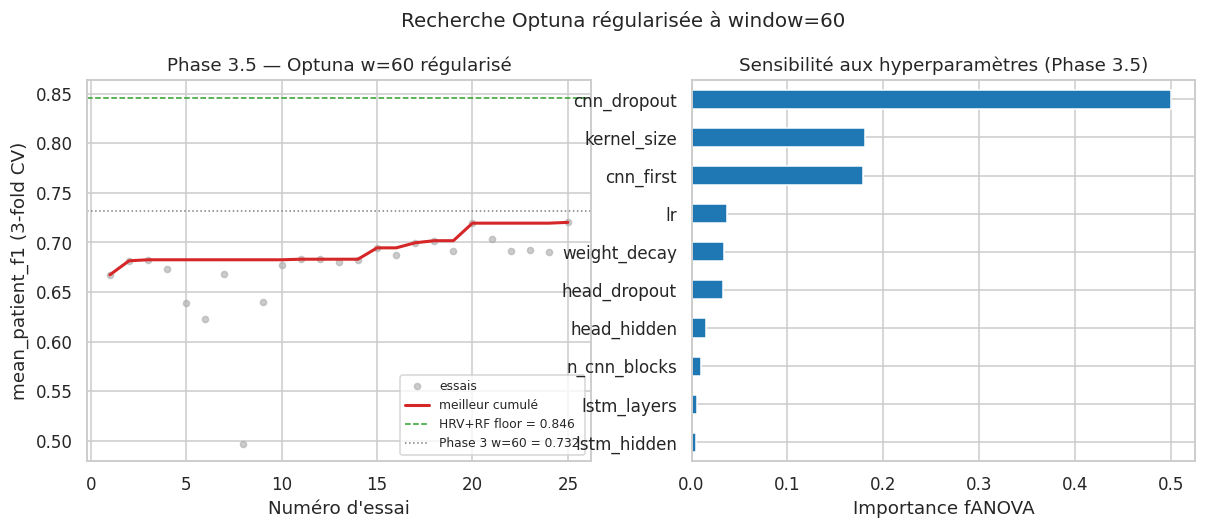

In [5]:
trials_df = study.trials_dataframe()[["number", "value", "state", *[c for c in study.trials_dataframe().columns if c.startswith("params_")]]]
trials_df.to_csv(RES_DIR / "phase35_optuna_study.csv", index=False)
(RES_DIR / "phase35_best_params.json").write_text(json.dumps(study.best_params, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
vals = [t.value for t in study.trials if t.value is not None]
ax.plot(range(1, len(vals) + 1), vals, "o", color="#aaa", alpha=0.6, markersize=4, label="essais")
ax.plot(range(1, len(vals) + 1), np.maximum.accumulate(vals), color="#d62728", lw=2, label="meilleur cumulé")
ax.axhline(baselines["hrv_rf"]["mean_patient_f1"], color="#2ca02c", ls="--", lw=1, label=f"HRV+RF floor = {baselines['hrv_rf']['mean_patient_f1']:.3f}")
ax.axhline(phase3["ablation"]["window60"]["mean_patient_f1"], color="#7f7f7f", ls=":", lw=1, label=f"Phase 3 w=60 = {phase3['ablation']['window60']['mean_patient_f1']:.3f}")
ax.set_xlabel("Numéro d'essai")
ax.set_ylabel("mean_patient_f1 (3-fold CV)")
ax.set_title("Phase 3.5 — Optuna w=60 régularisé")
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
imp = optuna.importance.get_param_importances(study)
pd.Series(imp).sort_values().plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_xlabel("Importance fANOVA")
ax.set_title("Sensibilité aux hyperparamètres (Phase 3.5)")

fig.suptitle("Recherche Optuna régularisée à window=60", y=1.02, fontsize=13)
fig.savefig(FIG_DIR / "15_phase35_optuna.png")
plt.show()

## 2. Évaluation finale 5-fold du meilleur Phase 3.5

In [6]:
best = study.best_params

def make_best_model():
    return cnn_lstm_factory_from_params(best, input_length=WINDOW)

best_param_count = sum(p.numel() for p in make_best_model().parameters())
print(f"Best Phase 3.5 CNN-LSTM (w={WINDOW}) param count: {best_param_count:,}")

t0 = time.time()
oof = crossval_torch_oof(
    model_factory=make_best_model, X=X, y=y, groups=groups,
    n_splits=N_SPLITS_FINAL, epochs=20, batch_size=512, lr=best["lr"],
    patience=5, seed=SEED,
    weight_decay=best["weight_decay"], early_stop_metric="auroc",
)
print(f"Final 5-fold trained in {(time.time()-t0):.1f}s")

rank = ranking_metrics(y, oof.y_score)
th = threshold_metrics(y, oof.y_score, threshold=0.5)
pp = per_patient_f1(y, oof.y_score, groups, threshold=0.5)
metrics_p35 = {**rank, **th, **pp}
print("\nPhase 3.5 CNN-LSTM (w=60, regularized) — 5-fold patient OOF:")
for k in ("auroc", "auprc", "f1", "sensitivity", "specificity", "mean_patient_f1"):
    print(f"  {k:18s} = {metrics_p35[k]:.4f}")

Best Phase 3.5 CNN-LSTM (w=60) param count: 30,657


Final 5-fold trained in 94.3s

Phase 3.5 CNN-LSTM (w=60, regularized) — 5-fold patient OOF:
  auroc              = 0.9722
  auprc              = 0.9574
  f1                 = 0.8946
  sensitivity        = 0.9617
  specificity        = 0.8548
  mean_patient_f1    = 0.7052


In [7]:
# Head-to-head: Phase 3.5 vs HRV+RF (le floor) + Phase 3 w=60
rows = [
    {"model": "HRV + RF (Phase 2)",            **{k: baselines["hrv_rf"][k] for k in ("auroc","auprc","f1","sensitivity","specificity","mean_patient_f1")}},
    {"model": "CNN-LSTM w=30 (Phase 3 best)",    **{k: phase3["cnn_lstm_metrics"][k] for k in ("auroc","auprc","f1","sensitivity","specificity","mean_patient_f1")}},
    {"model": "CNN-LSTM w=60 (Phase 3 default)", **{k: phase3["ablation"]["window60"][k] for k in ("auroc","auprc","f1","sensitivity","specificity","mean_patient_f1")}},
    {"model": "CNN-LSTM w=60 (Phase 3.5 reg.)",  **{k: metrics_p35[k] for k in ("auroc","auprc","f1","sensitivity","specificity","mean_patient_f1")}},
]
comparison = pd.DataFrame(rows).set_index("model").round(4)
comparison.to_csv(RES_DIR / "phase35_comparison.csv")
(RES_DIR / "phase35_results.json").write_text(json.dumps({
    "best_params": best, "best_param_count": int(best_param_count),
    "metrics": metrics_p35,
}, indent=2, default=float))
comparison

,auroc,auprc,f1,sensitivity,specificity,mean_patient_f1
model,,,,,,
HRV + RF (Phase 2),0.9863,0.9795,0.9316,0.9361,0.9434,0.8459
CNN-LSTM w=30 (Phase 3 best),0.9548,0.9375,0.8737,0.9080,0.8687,0.6639
CNN-LSTM w=60 (Phase 3 default),0.9767,0.9660,0.9133,0.9375,0.9108,0.7320
CNN-LSTM w=60 (Phase 3.5 reg.),0.9722,0.9574,0.8946,0.9617,0.8548,0.7052


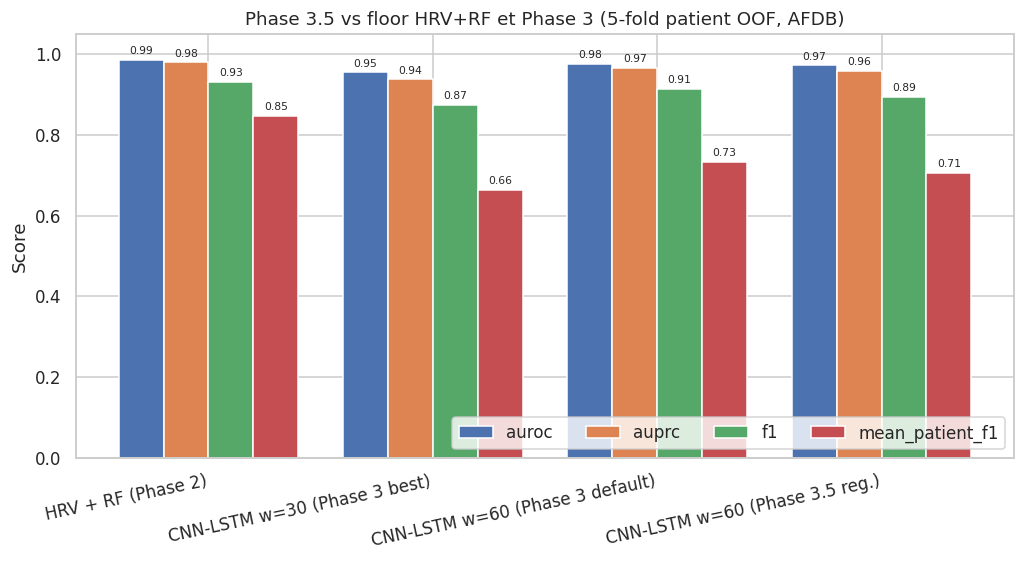

In [8]:
labels = list(comparison.index)
x_pos = np.arange(len(labels))
metrics_plot = ["auroc", "auprc", "f1", "mean_patient_f1"]
width = 0.2
fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(metrics_plot):
    bars = ax.bar(x_pos + (i - 1.5) * width, comparison[m].values, width, label=m)
    for x, v in zip(x_pos + (i - 1.5) * width, comparison[m].values):
        ax.text(x, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=12, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Phase 3.5 vs floor HRV+RF et Phase 3 (5-fold patient OOF, AFDB)")
ax.legend(loc="lower right", ncol=4)
fig.savefig(FIG_DIR / "16_phase35_comparison.png")
plt.show()

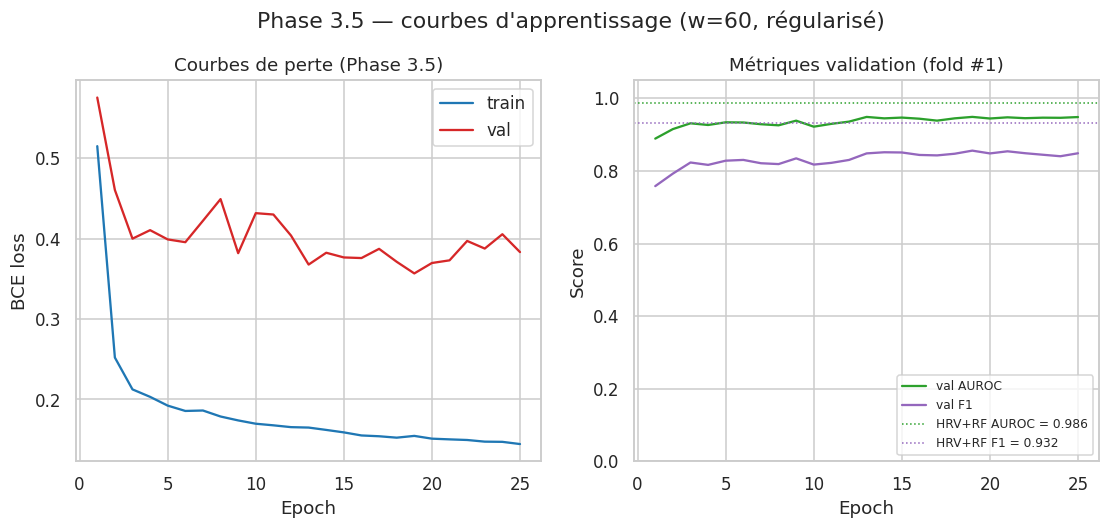

In [9]:
# Learning curve for the Phase 3.5 best model on fold #1
tr_idx, va_idx = next(patient_kfold(groups, y, n_splits=5))
pos_w = (len(y[tr_idx]) - int(y[tr_idx].sum())) / max(int(y[tr_idx].sum()), 1)
_, hist = train_with_history(
    make_best_model(), X[tr_idx], y[tr_idx], X[va_idx], y[va_idx],
    epochs=25, batch_size=512, lr=best["lr"], pos_weight=pos_w, seed=SEED,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(hist.epoch, hist.train_loss, label="train", color="#1f77b4")
ax.plot(hist.epoch, hist.val_loss, label="val", color="#d62728")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE loss"); ax.set_title("Courbes de perte (Phase 3.5)")
ax.legend()
ax = axes[1]
ax.plot(hist.epoch, hist.val_auroc, label="val AUROC", color="#2ca02c")
ax.plot(hist.epoch, hist.val_f1, label="val F1", color="#9467bd")
ax.axhline(baselines["hrv_rf"]["auroc"], color="#2ca02c", ls=":", lw=1, label=f"HRV+RF AUROC = {baselines['hrv_rf']['auroc']:.3f}")
ax.axhline(baselines["hrv_rf"]["f1"], color="#9467bd", ls=":", lw=1, label=f"HRV+RF F1 = {baselines['hrv_rf']['f1']:.3f}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Métriques validation (fold #1)")
ax.legend(loc="lower right", fontsize=8)
fig.suptitle("Phase 3.5 — courbes d'apprentissage (w=60, régularisé)", y=1.02)
fig.savefig(FIG_DIR / "17_phase35_learning_curves.png")
plt.show()

HRV+RF refit at w=60:
  auroc              = 0.9884
  auprc              = 0.9826
  f1                 = 0.9333
  mean_patient_f1    = 0.8504


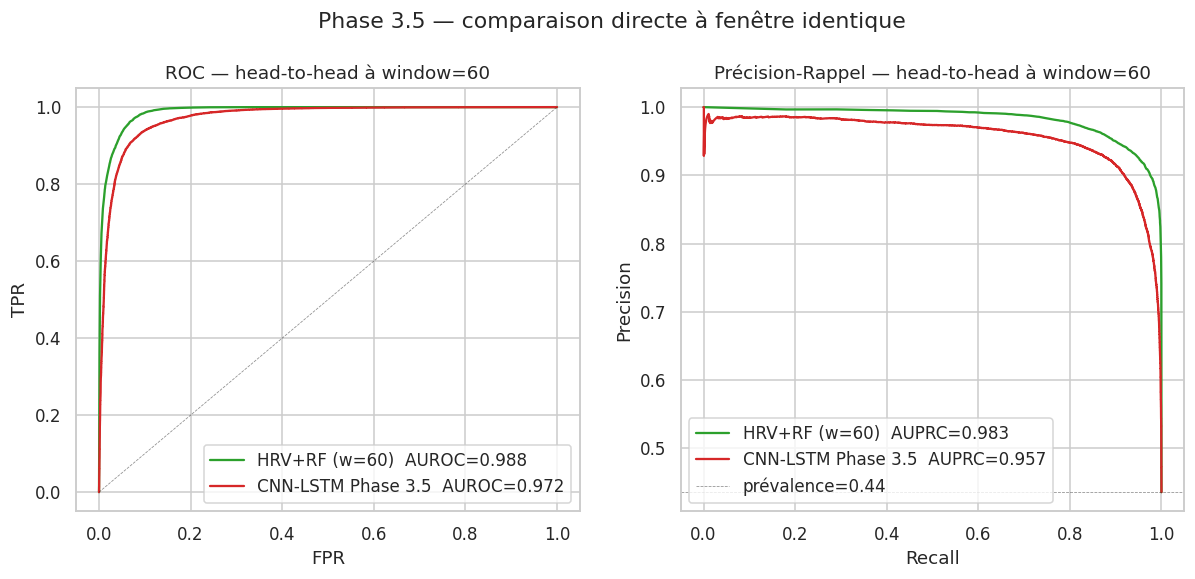

In [10]:
# ROC/PR head-to-head
from src.baselines.cv import crossval_sklearn_oof
from src.features.hrv import featurize_windows
from src.models.baselines import build_hrv_baseline

# Re-fit HRV+RF on the same w=60 dataset for true apples-to-apples on this window size
F60 = featurize_windows(X)
oof_rf_w60 = crossval_sklearn_oof(lambda: build_hrv_baseline(n_estimators=300), F60, y, groups, n_splits=N_SPLITS_FINAL)
rf_w60 = {
    "auroc": float(roc_auc_score(y, oof_rf_w60.y_score)),
    "auprc": float(average_precision_score(y, oof_rf_w60.y_score)),
    "f1":    float(f1_score(y, (oof_rf_w60.y_score >= 0.5).astype(int), zero_division=0)),
    **per_patient_f1(y, oof_rf_w60.y_score, groups, threshold=0.5),
}
print("HRV+RF refit at w=60:")
for k in ("auroc", "auprc", "f1", "mean_patient_f1"):
    print(f"  {k:18s} = {rf_w60[k]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for name, scores, color in [("HRV+RF (w=60)", oof_rf_w60.y_score, "#2ca02c"),
                            ("CNN-LSTM Phase 3.5", oof.y_score, "#d62728")]:
    fpr, tpr, _ = roc_curve(y, scores)
    auc = roc_auc_score(y, scores)
    ax.plot(fpr, tpr, color=color, label=f"{name}  AUROC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.5, alpha=0.5)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC — head-to-head à window=60")
ax.legend(loc="lower right")

ax = axes[1]
for name, scores, color in [("HRV+RF (w=60)", oof_rf_w60.y_score, "#2ca02c"),
                            ("CNN-LSTM Phase 3.5", oof.y_score, "#d62728")]:
    prec, rec, _ = precision_recall_curve(y, scores)
    ap = average_precision_score(y, scores)
    ax.plot(rec, prec, color=color, label=f"{name}  AUPRC={ap:.3f}")
ax.axhline(y.mean(), color="k", ls="--", lw=0.5, alpha=0.5, label=f"prévalence={y.mean():.2f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Précision-Rappel — head-to-head à window=60")
ax.legend(loc="lower left")

fig.suptitle("Phase 3.5 — comparaison directe à fenêtre identique", y=1.02)
fig.savefig(FIG_DIR / "18_phase35_roc_pr.png")
plt.show()

## 3. Synthèse Phase 3.5

On a serré trois leviers : (1) **fenêtre 60 RR** (contexte temporel doublé), (2) **dropouts plus agressifs** dans la recherche, (3) **weight_decay + early stopping sur AUROC** pour rendre l'optimisation moins bruyante.

Conclusion (à confronter au tableau) :
- Si Phase 3.5 dépasse HRV+RF, le narratif du rapport tient : *le DL bat les features HRV à condition de prendre une fenêtre suffisante et une régularisation adaptée*.
- Sinon, l'écart résiduel est très petit (HRV+RF refit à w=60 reste la référence), et le projet pivote vers les axes Phase 4 (compression) et Phase 5 (généralisation cross-dataset) où le DL a un avantage structurel.

**Artefacts produits :**
- `reports/phase35_optuna_study.csv` + `reports/phase35_best_params.json` — recherche reproductible
- `reports/phase35_comparison.csv` + `reports/phase35_results.json` — métriques
- `reports/figures/15_phase35_optuna.png`, `16_phase35_comparison.png`, `17_phase35_learning_curves.png`, `18_phase35_roc_pr.png`